**Supervised Learning**

In [91]:
print("hello")

hello


In [92]:
# Extract the csv file
import pandas as pd
fitbitdf = pd.read_csv("Fitbit_dataset.csv")
display(fitbitdf)



,Unnamed: 0,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Base_MET,HR_Intensity,Effective_MET,Calories_Burned (kcal)
0,0,56,Female,53.8,1.62,163.0,149.0,71.0,1.01,HIIT,22.1,3.5,3,1,20.4,9.5,0.847826,8.054348,437.7
1,1,46,Male,54.9,1.75,170.0,126.0,73.0,0.25,Yoga,19.9,3.4,3,0,18.0,3.0,0.546392,1.639175,22.5
2,2,32,Female,68.5,1.61,190.0,171.0,60.0,0.33,HIIT,20.4,2.7,3,1,26.5,9.5,0.853846,8.111538,183.4
3,3,25,Male,98.8,1.86,189.0,135.0,69.0,0.78,Yoga,30.3,4.4,3,0,28.5,3.0,0.550000,1.650000,127.2
4,4,38,Male,95.5,1.71,176.0,138.0,66.0,0.55,Cardio,23.7,2.2,2,0,32.5,7.0,0.654545,4.581818,240.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14097,14097,18,Male,75.7,1.76,205.0,143.0,67.0,0.62,Yoga,23.3,3.7,4,1,24.3,3.0,0.550725,1.652174,77.5
14098,14098,54,Male,66.4,1.71,162.0,131.0,73.0,0.93,Cardio,15.0,2.7,3,1,22.7,7.0,0.651685,4.561798,281.7
14099,14099,23,Female,74.7,1.52,204.0,161.0,61.0,0.99,Strength,19.3,4.3,3,1,32.5,6.0,0.699301,4.195804,310.3
14100,14100,43,Male,70.8,1.69,171.0,154.0,55.0,1.01,HIIT,12.3,3.9,7,3,24.9,9.5,0.853448,8.107759,579.8


In [93]:
# Finding the count of null values in the dataset
fitbitdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14102 entries, 0 to 14101
Data columns (total 19 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     14102 non-null  int64  
 1   Age                            14102 non-null  int64  
 2   Gender                         14102 non-null  object 
 3   Weight (kg)                    14102 non-null  float64
 4   Height (m)                     14102 non-null  float64
 5   Max_BPM                        14102 non-null  float64
 6   Avg_BPM                        14102 non-null  float64
 7   Resting_BPM                    14102 non-null  float64
 8   Session_Duration (hours)       14102 non-null  float64
 9   Workout_Type                   14102 non-null  object 
 10  Fat_Percentage                 14102 non-null  float64
 11  Water_Intake (liters)          14102 non-null  float64
 12  Workout_Frequency (days/week)  14102 non-null 

In [94]:
fitbitdf.isnull().sum()

Unnamed: 0                       0
Age                              0
Gender                           0
Weight (kg)                      0
Height (m)                       0
Max_BPM                          0
Avg_BPM                          0
Resting_BPM                      0
Session_Duration (hours)         0
Workout_Type                     0
Fat_Percentage                   0
Water_Intake (liters)            0
Workout_Frequency (days/week)    0
Experience_Level                 0
BMI                              0
Base_MET                         0
HR_Intensity                     0
Effective_MET                    0
Calories_Burned (kcal)           0
dtype: int64

In [95]:
# Finding duplicate rows in the dataframe
# Returns only the extra copies
duplicates = fitbitdf[fitbitdf.duplicated()]
print(fitbitdf.duplicated().sum())
display(duplicates)



0


,Unnamed: 0,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Base_MET,HR_Intensity,Effective_MET,Calories_Burned (kcal)


In [96]:
# Renaming the column names in dataframe
fitbitdf.columns = fitbitdf.columns.str.lower()
fitbitdf.dtypes

unnamed: 0                         int64
age                                int64
gender                            object
weight (kg)                      float64
height (m)                       float64
max_bpm                          float64
avg_bpm                          float64
resting_bpm                      float64
session_duration (hours)         float64
workout_type                      object
fat_percentage                   float64
water_intake (liters)            float64
workout_frequency (days/week)      int64
experience_level                   int64
bmi                              float64
base_met                         float64
hr_intensity                     float64
effective_met                    float64
calories_burned (kcal)           float64
dtype: object

In [97]:
# Removing special characters from the columns names
# 1. Replace spaces with underscores
fitbitdf.columns = fitbitdf.columns.str.replace(' ', '_')

# 2. Remove all other special characters (keeping the underscores)
fitbitdf.columns = fitbitdf.columns.str.replace(r'[^a-zA-Z0-9_]', '', regex=True)
fitbitdf.dtypes


unnamed_0                       int64
age                             int64
gender                         object
weight_kg                     float64
height_m                      float64
max_bpm                       float64
avg_bpm                       float64
resting_bpm                   float64
session_duration_hours        float64
workout_type                   object
fat_percentage                float64
water_intake_liters           float64
workout_frequency_daysweek      int64
experience_level                int64
bmi                           float64
base_met                      float64
hr_intensity                  float64
effective_met                 float64
calories_burned_kcal          float64
dtype: object

In [98]:
# 1. Get an array of all unique workout types
unique_workouts = fitbitdf['workout_type'].unique()
print("Unique Workout Types:", unique_workouts)

# 2. (Optional) Get unique values AND their counts to see the distribution
workout_counts = fitbitdf['workout_type'].value_counts()
print("\nCounts per Workout Type:")
print(workout_counts)

Unique Workout Types: ['HIIT' 'Yoga' 'Cardio' 'Mixed' 'Strength']

Counts per Workout Type:
workout_type
HIIT        2898
Strength    2838
Mixed       2822
Cardio      2774
Yoga        2770
Name: count, dtype: int64


In [99]:
# Encoding

# 1. Identify the categorical columns to encode
# From your image, these are 'gender' and 'workout_type'
categorical_cols = ['gender', 'workout_type']

# 2. Apply One-Hot Encoding using pd.get_dummies
# drop_first=True is often used to avoid the "dummy variable trap" (multicollinearity)
df_encoded = pd.get_dummies(fitbitdf, columns=categorical_cols, drop_first=False)

# 3. Display the first few rows of the new dataframe
display(df_encoded.head())



,unnamed_0,age,weight_kg,height_m,max_bpm,avg_bpm,resting_bpm,session_duration_hours,fat_percentage,water_intake_liters,...,hr_intensity,effective_met,calories_burned_kcal,gender_Female,gender_Male,workout_type_Cardio,workout_type_HIIT,workout_type_Mixed,workout_type_Strength,workout_type_Yoga
0,0,56,53.8,1.62,163.0,149.0,71.0,1.01,22.1,3.5,...,0.847826,8.054348,437.7,True,False,False,True,False,False,False
1,1,46,54.9,1.75,170.0,126.0,73.0,0.25,19.9,3.4,...,0.546392,1.639175,22.5,False,True,False,False,False,False,True
2,2,32,68.5,1.61,190.0,171.0,60.0,0.33,20.4,2.7,...,0.853846,8.111538,183.4,True,False,False,True,False,False,False
3,3,25,98.8,1.86,189.0,135.0,69.0,0.78,30.3,4.4,...,0.550000,1.650000,127.2,False,True,False,False,False,False,True
4,4,38,95.5,1.71,176.0,138.0,66.0,0.55,23.7,2.2,...,0.654545,4.581818,240.7,False,True,True,False,False,False,False


In [100]:
# Save the cleaned dataframe in a csv file
fitbitdf.to_csv("cleaned.csv",index=False)

In [101]:
# Dataframe after encoding
df_encoded.dtypes

unnamed_0                       int64
age                             int64
weight_kg                     float64
height_m                      float64
max_bpm                       float64
avg_bpm                       float64
resting_bpm                   float64
session_duration_hours        float64
fat_percentage                float64
water_intake_liters           float64
workout_frequency_daysweek      int64
experience_level                int64
bmi                           float64
base_met                      float64
hr_intensity                  float64
effective_met                 float64
calories_burned_kcal          float64
gender_Female                    bool
gender_Male                      bool
workout_type_Cardio              bool
workout_type_HIIT                bool
workout_type_Mixed               bool
workout_type_Strength            bool
workout_type_Yoga                bool
dtype: object

In [102]:
# Cheking the skewness in the numerical data
# Calculate skewness for all numerical columns
skew_values = df_encoded.skew(numeric_only=True)
print(skew_values)


unnamed_0                     0.000000
age                           0.003135
weight_kg                     0.416550
height_m                     -0.012917
max_bpm                      -0.047057
avg_bpm                       0.185845
resting_bpm                  -0.069268
session_duration_hours        0.191875
fat_percentage               -0.094860
water_intake_liters           0.020722
workout_frequency_daysweek    0.392939
experience_level              0.443009
bmi                           0.275033
base_met                     -0.525490
hr_intensity                 -0.016123
effective_met                -0.032219
calories_burned_kcal          1.042262
gender_Female                 0.020142
gender_Male                  -0.020142
workout_type_Cardio           1.526109
workout_type_HIIT             1.457815
workout_type_Mixed            1.499273
workout_type_Strength         1.490442
workout_type_Yoga             1.528369
dtype: float64


In [103]:
# Select a column to check, e.g., 'weight_kg'
Q1 = df_encoded['weight_kg'].quantile(0.25)
Q3 = df_encoded['weight_kg'].quantile(0.75)
IQR = Q3 - Q1

# Define boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter outliers
outliers = df_encoded[(df_encoded['weight_kg'] < lower_bound) | (df_encoded['weight_kg'] > upper_bound)]
display(outliers)


,unnamed_0,age,weight_kg,height_m,max_bpm,avg_bpm,resting_bpm,session_duration_hours,fat_percentage,water_intake_liters,...,hr_intensity,effective_met,calories_burned_kcal,gender_Female,gender_Male,workout_type_Cardio,workout_type_HIIT,workout_type_Mixed,workout_type_Strength,workout_type_Yoga
95,95,59,110.5,1.87,162.0,134.0,68.0,0.25,28.9,2.5,...,0.702128,4.212766,116.4,True,False,False,False,False,True,False
144,144,39,106.9,1.77,181.0,131.0,71.0,1.01,20.6,4.6,...,0.545455,1.636364,176.7,True,False,False,False,False,False,True
172,172,32,118.1,1.90,188.0,139.0,80.0,0.50,26.9,3.4,...,0.546296,1.638889,96.8,True,False,False,False,False,False,True
203,203,51,106.9,1.82,176.0,145.0,73.0,0.96,22.2,3.2,...,0.699029,4.194175,430.4,False,True,False,False,False,True,False
295,295,51,107.8,1.88,172.0,136.0,69.0,1.03,22.0,3.3,...,0.650485,4.553398,505.6,False,True,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13355,13355,25,112.3,1.88,189.0,138.0,75.0,0.57,20.8,3.4,...,0.552632,1.657895,106.1,False,True,False,False,False,False,True
13448,13448,58,106.8,1.81,158.0,130.0,64.0,0.82,20.2,3.6,...,0.702128,4.212766,368.9,False,True,False,False,False,True,False
13461,13461,42,108.9,1.87,180.0,151.0,63.0,0.99,24.9,3.6,...,0.752137,6.017094,648.7,True,False,False,False,True,False,False
13580,13580,31,110.8,1.87,194.0,147.0,60.0,0.97,16.1,2.7,...,0.649254,4.544776,488.5,True,False,True,False,False,False,False


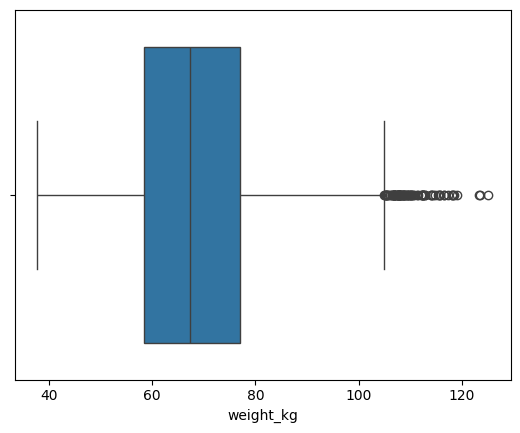

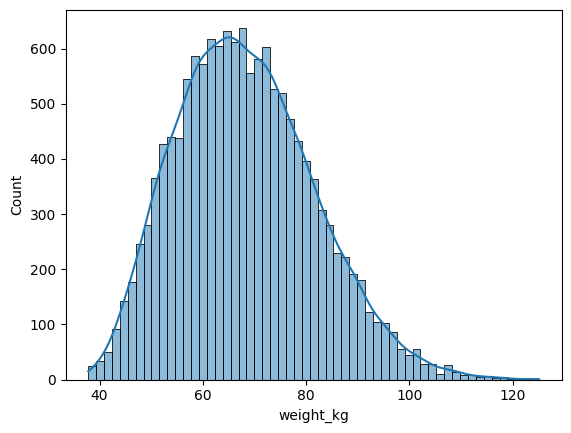

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns

# Boxplot for outliers
sns.boxplot(x=df_encoded['weight_kg'])
plt.show()

# Histogram for skewness
sns.histplot(df_encoded['weight_kg'], kde=True)
plt.show()


In [105]:
# Identify numerical columns to clean
cols = ['weight_kg', 'height_m', 'fat_percentage']

for col in cols:
    Q1 = df_encoded[col].quantile(0.25)
    Q3 = df_encoded[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Keep only rows within the boundaries
    df_encoded = df_encoded[(df_encoded[col] >= lower) & (df_encoded[col] <= upper)]

print(f"Dataset size after removal: {df_encoded.shape}")


Dataset size after removal: (13999, 24)


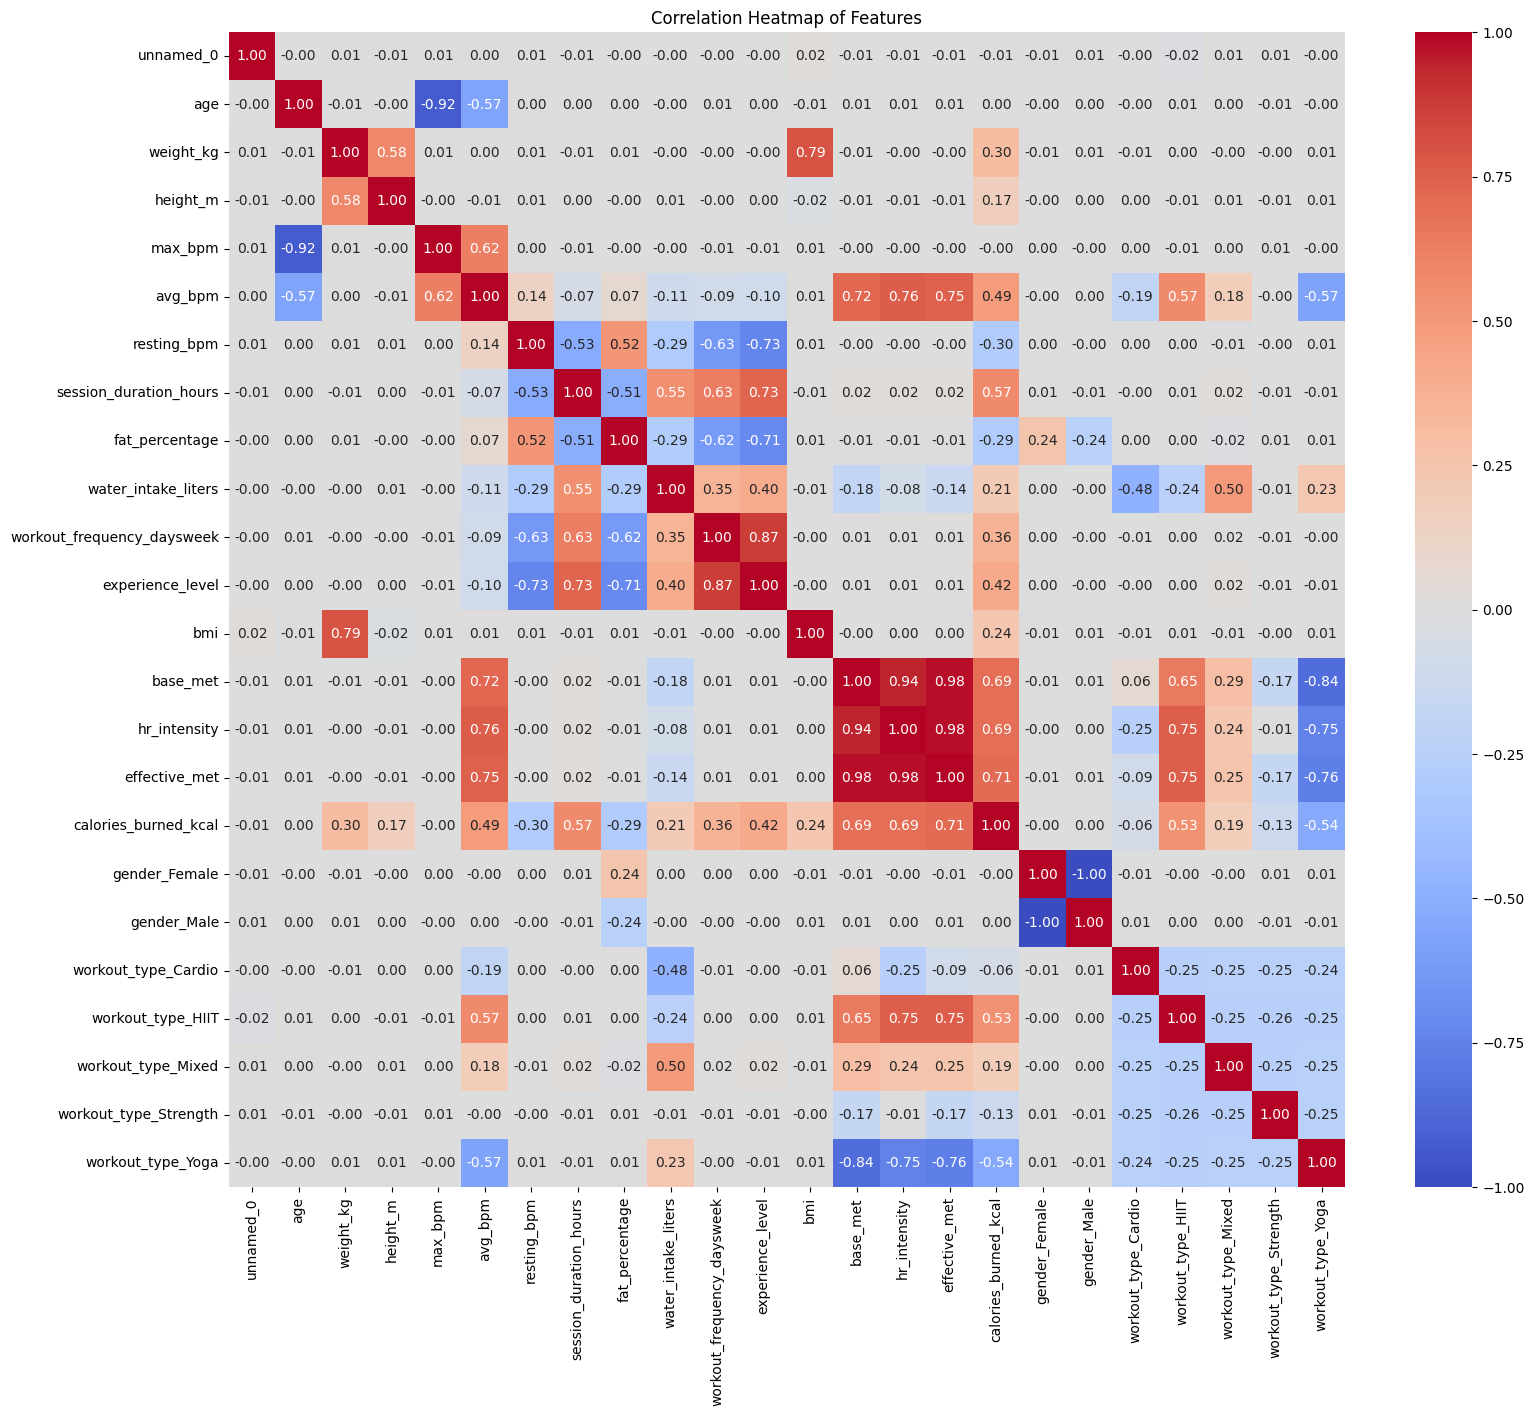

In [106]:
# generating the correlation heatmap for feature selection
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix
correlation_matrix = df_encoded.corr(numeric_only=True)

# Plotting the heatmap
plt.figure(figsize=(18, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Features')
plt.show()

In [107]:
# Get correlations with 'calories_burned_kcal'
correlations_with_calories = correlation_matrix['calories_burned_kcal'].sort_values(ascending=False)

# Display the top correlated features (excluding itself)
print("Features most highly correlated with 'calories_burned_kcal':")
display(correlations_with_calories[1:])


Features most highly correlated with 'calories_burned_kcal':


effective_met                 0.706736
base_met                      0.694761
hr_intensity                  0.689987
session_duration_hours        0.574999
workout_type_HIIT             0.532533
avg_bpm                       0.490328
experience_level              0.417248
workout_frequency_daysweek    0.361968
weight_kg                     0.300190
bmi                           0.242062
water_intake_liters           0.210229
workout_type_Mixed            0.185693
height_m                      0.171219
gender_Male                   0.004844
age                           0.003356
max_bpm                      -0.003256
gender_Female                -0.004844
unnamed_0                    -0.010326
workout_type_Cardio          -0.063439
workout_type_Strength        -0.128982
fat_percentage               -0.294270
resting_bpm                  -0.296686
workout_type_Yoga            -0.535381
Name: calories_burned_kcal, dtype: float64

In [108]:
# Define a threshold for 'highly correlated'
correlation_threshold = 0.5

# Filter features with absolute correlation greater than or equal to the threshold
highly_correlated_features = correlations_with_calories[
    (correlations_with_calories.abs() >= correlation_threshold) &
    (correlations_with_calories.index != 'calories_burned_kcal')
].index.tolist()

print(f"Features highly correlated with 'calories_burned_kcal' (absolute correlation >= {correlation_threshold}):")
print(highly_correlated_features)

Features highly correlated with 'calories_burned_kcal' (absolute correlation >= 0.5):
['effective_met', 'base_met', 'hr_intensity', 'session_duration_hours', 'workout_type_HIIT', 'workout_type_Yoga']


In [109]:
# Selecting Features and Target

feature=df_encoded[[
                    'effective_met',
                    'base_met',
                    #'hr_intensity',
                    'session_duration_hours','weight_kg','bmi','height_m']] #Feature x
target=df_encoded['calories_burned_kcal'] #Target y
print(feature)
print(target)

       effective_met  base_met  session_duration_hours  weight_kg   bmi  \
0           8.054348       9.5                    1.01       53.8  20.4   
1           1.639175       3.0                    0.25       54.9  18.0   
2           8.111538       9.5                    0.33       68.5  26.5   
3           1.650000       3.0                    0.78       98.8  28.5   
4           4.581818       7.0                    0.55       95.5  32.5   
...              ...       ...                     ...        ...   ...   
14097       1.652174       3.0                    0.62       75.7  24.3   
14098       4.561798       7.0                    0.93       66.4  22.7   
14099       4.195804       6.0                    0.99       74.7  32.5   
14100       8.107759       9.5                    1.01       70.8  24.9   
14101       4.567376       7.0                    0.97       87.3  34.2   

       height_m  
0          1.62  
1          1.75  
2          1.61  
3          1.86  
4        

In [110]:
# Spliting Data
from sklearn.model_selection import train_test_split


# Split data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(feature, target, test_size=0.2, random_state=4)

In [111]:
#Standard Scaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Initialize StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [112]:
from sklearn import metrics
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

# Train Linear Regression Model -  1
linear_model = LinearRegression()
linear_model.fit(x_train_scaled, y_train)
y_pred_standard = linear_model.predict(x_test_scaled) # Make prediction on test set

# Evaluate (MAE,MSE,RMSE) Formula
print("\nStandardScaler Results:")
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred_standard))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred_standard))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred_standard)))
print('R-squared:', r2_score(y_test, y_pred_standard))



StandardScaler Results:
Mean Absolute Error: 34.485025252022474
Mean Squared Error: 2791.6144120360855
Root Mean Squared Error: 52.83573044859024
R-squared: 0.9079582362039529


### Hyperparameter Tuning for Regularized Linear Regression (Ridge)

While standard `LinearRegression` doesn't typically have hyperparameters to tune (as it's a closed-form solution or solved via gradient descent without explicit regularization strength), its regularized variants like Ridge, Lasso, or ElasticNet do. We'll demonstrate hyperparameter tuning using `Ridge` regression with `GridSearchCV` to find the optimal `alpha` (regularization strength).

In [113]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Define the Ridge Regressor model
ridge = Ridge()

# Define the parameter grid to search
param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}

# Initialize GridSearchCV
# cv=5 means 5-fold cross-validation
# scoring='neg_mean_squared_error' is used because GridSearchCV maximizes the score, so we negate MSE
grid_search_ridge = GridSearchCV(ridge, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

# Fit GridSearchCV to the scaled training data
grid_search_ridge.fit(x_train_scaled, y_train)

# Get the best parameters and best score
best_alpha = grid_search_ridge.best_params_['alpha']
best_score = -grid_search_ridge.best_score_ # Negate back to positive MSE

print(f"Best alpha for Ridge Regression: {best_alpha}")
print(f"Best cross-validation MSE for Ridge Regression: {best_score}")

Best alpha for Ridge Regression: 1
Best cross-validation MSE for Ridge Regression: 2633.1448583261117


In [114]:
# Train a Ridge model with the best alpha found
ridge_tuned_model = Ridge(alpha=best_alpha)
ridge_tuned_model.fit(x_train_scaled, y_train)
y_pred_ridge_tuned = ridge_tuned_model.predict(x_test_scaled)

# Evaluate the tuned Ridge Model
print("\nTuned Ridge Regressor Results:")
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred_ridge_tuned))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred_ridge_tuned))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred_ridge_tuned)))
print('R-squared:', r2_score(y_test, y_pred_ridge_tuned))


Tuned Ridge Regressor Results:
Mean Absolute Error: 34.486046597021044
Mean Squared Error: 2792.0683789289747
Root Mean Squared Error: 52.840026295687764
R-squared: 0.9079432685517778


In [115]:
# KNN Model -  2
from sklearn.neighbors import KNeighborsRegressor

# Train K-Nearest Neighbors Regression
knn_model = KNeighborsRegressor(n_neighbors=5) # You can adjust n_neighbors
knn_model.fit(x_train_scaled, y_train)
y_pred_knn = knn_model.predict(x_test_scaled) # Make prediction on test set

In [116]:
# Evaluate KNN Model
print("\nKNN Regressor Results:")
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred_knn))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred_knn))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred_knn)))
print('R-squared:', r2_score(y_test, y_pred_knn))


KNN Regressor Results:
Mean Absolute Error: 7.519442857142858
Mean Squared Error: 148.35347742857147
Root Mean Squared Error: 12.1800442293356
R-squared: 0.9951086669889185


In [117]:
# Random Forest Model - 3
from sklearn.ensemble import RandomForestRegressor

# Train Random Forest Regressor
# You can adjust parameters like n_estimators, random_state, etc.
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(x_train_scaled, y_train)
y_pred_rf = rf_model.predict(x_test_scaled) # Make prediction on test set

In [118]:
# Evaluate Random Forest Model
print("\nRandom Forest Regressor Results:")
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred_rf))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred_rf))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred_rf)))
print('R-squared:', r2_score(y_test, y_pred_rf))


Random Forest Regressor Results:
Mean Absolute Error: 2.9376971428571363
Mean Squared Error: 32.942813230714144
Root Mean Squared Error: 5.73958301888858
R-squared: 0.9989138490541224


In [119]:
# Decision Tree Model - 4
from sklearn.tree import DecisionTreeRegressor

# Train Decision Tree Regressor
# You can adjust parameters like random_state, max_depth, etc.
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(x_train_scaled, y_train)
y_pred_dt = dt_model.predict(x_test_scaled) # Make prediction on test set

In [120]:
# Evaluate Decision Tree Model
print("\nDecision Tree Regressor Results:")
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred_dt))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred_dt))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred_dt)))
print('R-squared:', r2_score(y_test, y_pred_dt))


Decision Tree Regressor Results:
Mean Absolute Error: 6.451107142857143
Mean Squared Error: 115.88053214285713
Root Mean Squared Error: 10.764782029509801
R-squared: 0.9961793260121931


In [121]:
# XGBoost Regressor - Model 5
from xgboost import XGBRegressor
from sklearn import metrics
from sklearn.metrics import r2_score
import numpy as np

# Train XGBoost Regressor
xgb_model = XGBRegressor(random_state=42) # You can adjust parameters here
xgb_model.fit(x_train_scaled, y_train)
y_pred_xgb = xgb_model.predict(x_test_scaled) # Make prediction on test set

# Evaluate XGBoost Model
print("\nXGBoost Regressor Results:")
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred_xgb))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred_xgb))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred_xgb)))
print('R-squared:', r2_score(y_test, y_pred_xgb))


XGBoost Regressor Results:
Mean Absolute Error: 4.86873124899183
Mean Squared Error: 50.203023638040314
Root Mean Squared Error: 7.085409207522196
R-squared: 0.9983447660881756


In [122]:
# Support Vector Regressor (SVR) - Model 6
from sklearn.svm import SVR

# Train SVR Model
# You can adjust parameters like kernel, C, gamma, etc.
# SVR can be computationally intensive on larger datasets, consider using a smaller subset or linear SVR if it's too slow.
svr_model = SVR(kernel='rbf')
svr_model.fit(x_train_scaled, y_train)
y_pred_svr = svr_model.predict(x_test_scaled) # Make prediction on test set

In [123]:
# Evaluate SVR Model
print("\nSupport Vector Regressor Results:")
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred_svr))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred_svr))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred_svr)))
print('R-squared:', r2_score(y_test, y_pred_svr))


Support Vector Regressor Results:
Mean Absolute Error: 18.15209641957187
Mean Squared Error: 2395.66568562362
Root Mean Squared Error: 48.94553795417535
R-squared: 0.9210129829464377


In [124]:
import pandas as pd
import numpy as np
from sklearn import metrics
from sklearn.metrics import r2_score

# Assuming y_test, y_pred_standard, y_pred_knn, y_pred_rf, y_pred_dt, y_pred_xgb, y_pred_svr are available from previous runs

results = {
    'Model': [],
    'MAE': [],
    'MSE': [],
    'RMSE': [],
    'R-squared': []
}

def add_model_results(model_name, y_true, y_pred, results_dict):
    results_dict['Model'].append(model_name)
    results_dict['MAE'].append(metrics.mean_absolute_error(y_true, y_pred))
    results_dict['MSE'].append(metrics.mean_squared_error(y_true, y_pred))
    results_dict['RMSE'].append(np.sqrt(metrics.mean_squared_error(y_true, y_pred)))
    results_dict['R-squared'].append(r2_score(y_true, y_pred))

# Add results for each model (ensure y_pred_standard, y_pred_knn, etc., are in scope)
add_model_results('Linear Regression', y_test, y_pred_standard, results)
add_model_results('KNN Regressor', y_test, y_pred_knn, results)
add_model_results('Random Forest Regressor', y_test, y_pred_rf, results)
add_model_results('Decision Tree Regressor', y_test, y_pred_dt, results)
add_model_results('XGBoost Regressor', y_test, y_pred_xgb, results)
add_model_results('Support Vector Regressor', y_test, y_pred_svr, results)

# Create DataFrame
results_df = pd.DataFrame(results)

# Display the tabulated results, sorted by R-squared for easy comparison
print("\n--- Model Performance Metrics ---")
display(results_df.sort_values(by='R-squared', ascending=False))


--- Model Performance Metrics ---


,Model,MAE,MSE,RMSE,R-squared
2,Random Forest Regressor,2.937697,32.942813,5.739583,0.998914
4,XGBoost Regressor,4.868731,50.203024,7.085409,0.998345
3,Decision Tree Regressor,6.451107,115.880532,10.764782,0.996179
1,KNN Regressor,7.519443,148.353477,12.180044,0.995109
5,Support Vector Regressor,18.152096,2395.665686,48.945538,0.921013
0,Linear Regression,34.485025,2791.614412,52.835730,0.907958


In [125]:
import pickle

# Save the Linear Regression model to a file
filename = 'linear_regression_model.pkl'
pickle.dump(linear_model, open(filename, 'wb'))

print(f"Linear Regression model successfully saved as '{filename}'")

Linear Regression model successfully saved as 'linear_regression_model.pkl'


**Unsupervised Learning**